Conducting Exploratory Data Analysis on Amnes Housing Data for predciting House Prices.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("train.csv")

In [6]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [8]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Number of Unique/Distinct entries per feature.

In [9]:
df.nunique()

Id               1460
MSSubClass         15
MSZoning            5
LotFrontage       110
LotArea          1073
                 ... 
MoSold             12
YrSold              5
SaleType            9
SaleCondition       6
SalePrice         663
Length: 81, dtype: int64

Extracting categorical features

In [10]:
new_df=df.copy()
df_categoric=new_df.select_dtypes(include=['object', 'category'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_3196\3418343237.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_categoric=new_df.select_dtypes(include=['object', 'category'])


1. Numnber of unique entries in Categoric features.
2. Since Max number of distinct entries is 25 (<5% of total entries), we can conduct One-Hot Encoding for handling all Categpric features

In [11]:
max(df_categoric.nunique())

25

In [12]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [13]:
null_count=df.isna().sum()
print(null_count[null_count>0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


Removing cloumn with almost every entry as NaN


In [14]:
df= df.drop(columns=['PoolQC'])
df= df.drop(columns=['Alley'])
df= df.drop(columns=['Fence'])
df= df.drop(columns=['MiscFeature'])

Step 1: Handling NA values

In [15]:
null_counts = df.isna().sum()
print(null_counts[null_counts > 0])

LotFrontage     259
MasVnrType      872
MasVnrArea        8
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
FireplaceQu     690
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64


In [16]:
mask = (null_count > 0) & (null_count < 90)
target_columns = null_count[mask].index

In [17]:
new_df = df[target_columns].copy()
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MasVnrArea    1452 non-null   float64
 1   BsmtQual      1423 non-null   str    
 2   BsmtCond      1423 non-null   str    
 3   BsmtExposure  1422 non-null   str    
 4   BsmtFinType1  1423 non-null   str    
 5   BsmtFinType2  1422 non-null   str    
 6   Electrical    1459 non-null   str    
 7   GarageType    1379 non-null   str    
 8   GarageYrBlt   1379 non-null   float64
 9   GarageFinish  1379 non-null   str    
 10  GarageQual    1379 non-null   str    
 11  GarageCond    1379 non-null   str    
dtypes: float64(2), str(10)
memory usage: 137.0 KB


1. Separate features into numerical and categorical
2. Conduct statistical analysis on numerical and frequency analysis on categorical.

In [18]:
df_numeric = new_df.select_dtypes(include=['number'])
df_categorical = new_df.select_dtypes(include=['object', 'category'])


C:\Users\DELL\AppData\Local\Temp\ipykernel_3196\1977394474.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_categorical = new_df.select_dtypes(include=['object', 'category'])


In [19]:
print(f"Numerical columns: {df_numeric.columns.tolist()}")
print(f"Categorical columns: {df_categorical.columns.tolist()}")

Numerical columns: ['MasVnrArea', 'GarageYrBlt']
Categorical columns: ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']


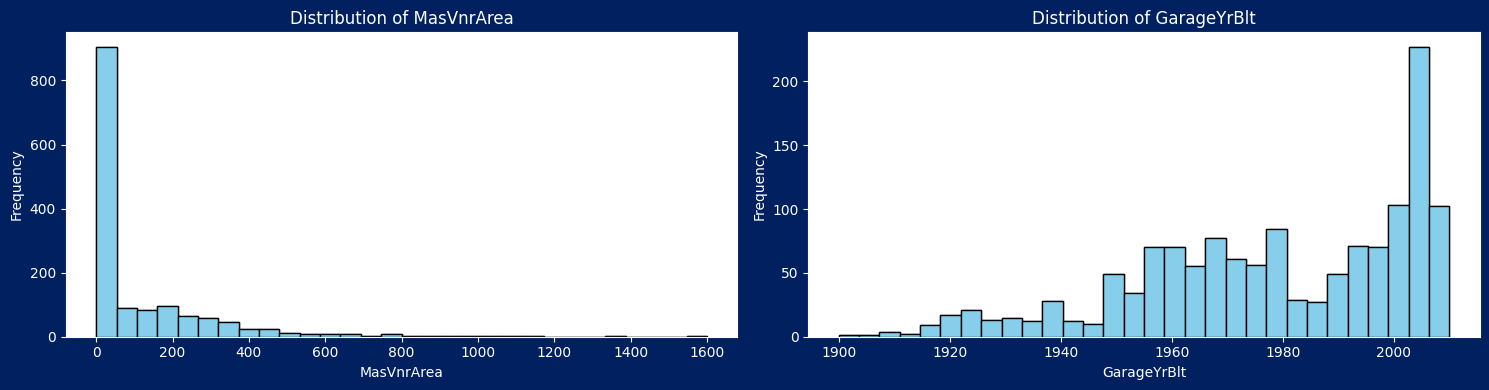

In [20]:
import matplotlib.pyplot as plt

# Assuming df_numeric is your numerical DataFrame
cols = df_numeric.columns
n_cols = 2
n_rows = (len(cols) - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4), facecolor='#002060')
axes = axes.flatten() # Flatten to iterate easily

for i, col in enumerate(cols):
    # Remove NaN values for the specific column to avoid plotting errors
    data = df_numeric[col].dropna()
    
    axes[i].hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

for i, col in enumerate(cols):
    data = df_numeric[col].dropna()
    axes[i].hist(data, bins=30, color='skyblue', edgecolor='black')
    
    # Set Title and Axis Labels to White
    axes[i].set_title(f'Distribution of {col}', color='white')
    axes[i].set_xlabel(col, color='white')
    axes[i].set_ylabel('Frequency', color='white')
    
    # Set the numbers on the axes (ticks) to White
    axes[i].tick_params(axis='x', colors='white')
    axes[i].tick_params(axis='y', colors='white')
    
    # Optional: Change the spine (border) color to white
    for spine in axes[i].spines.values():
        spine.set_edgecolor('white')

plt.tight_layout()
plt.show()



1. "MasVnrArea"  nan to zero
2. "GarageYrBlt" nan to median (non gausian dist)

In [21]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df_numeric['MasVnrArea'].median())

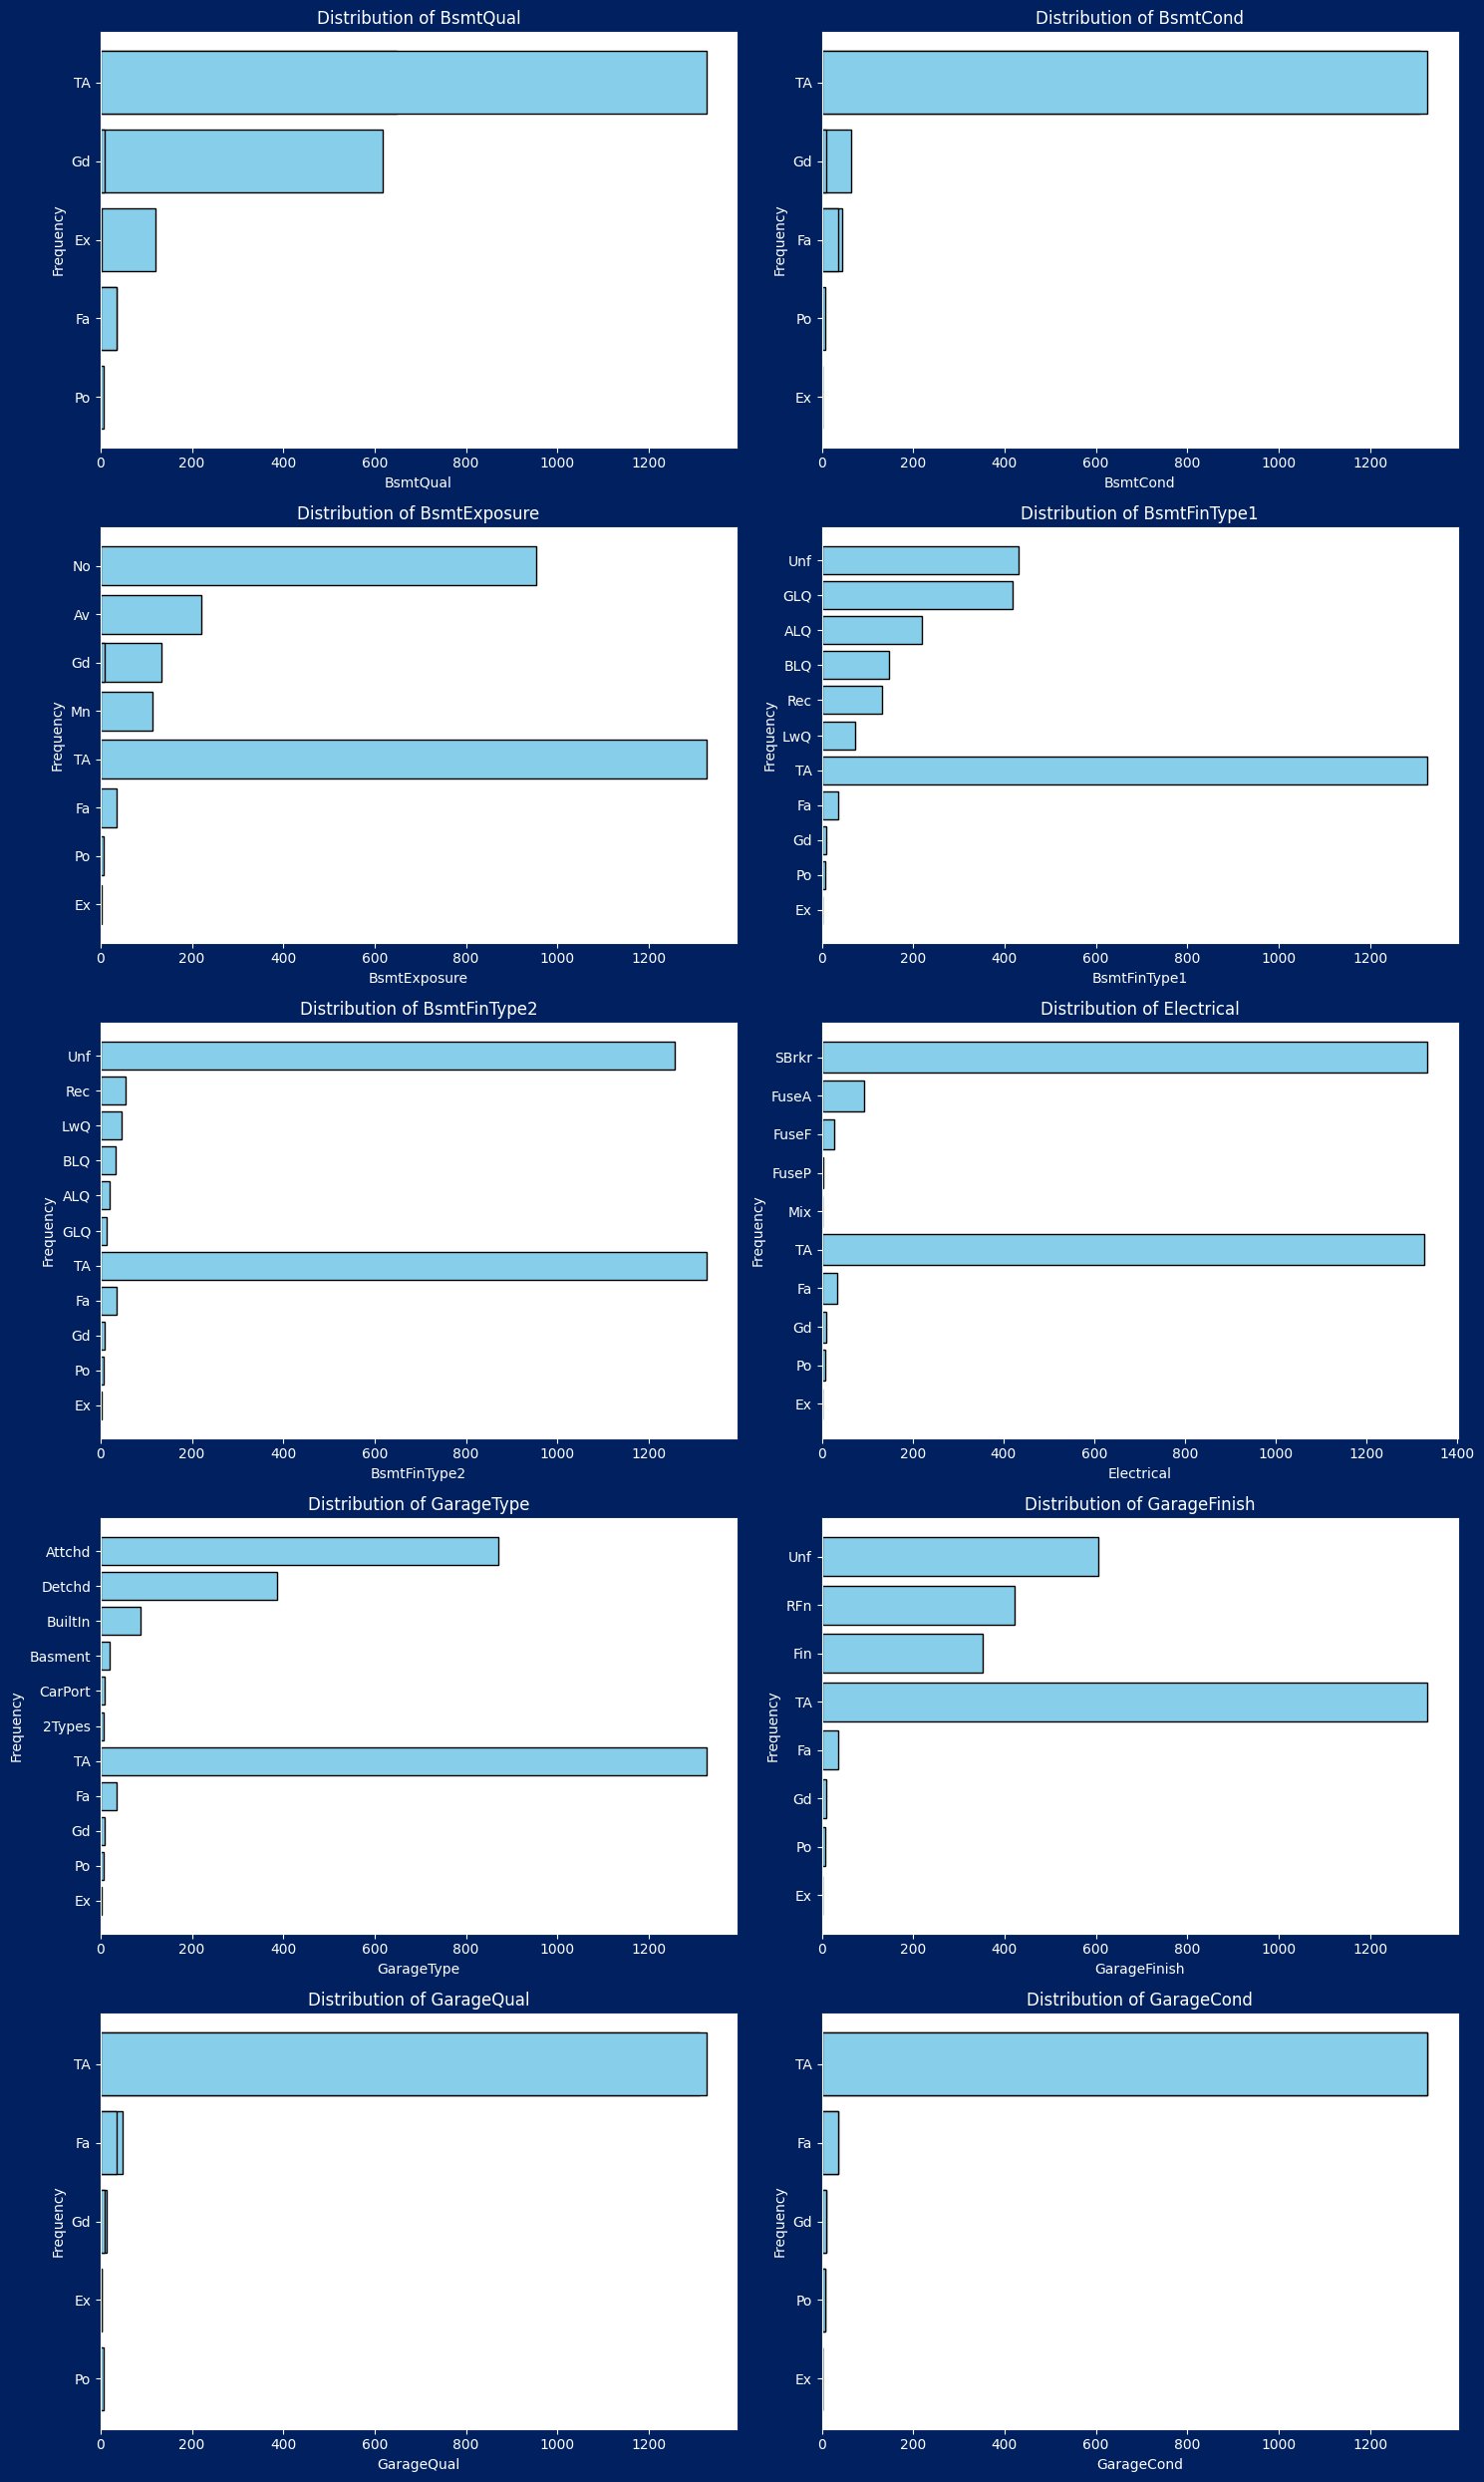

In [22]:
# Assuming df_categorical is your categorical DataFrame
cols = df_categorical.columns
n_cols = 2
n_rows = (len(cols) - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5),facecolor='#002060')
axes = axes.flatten()

for i, col in enumerate(cols):
    # Get counts and sort them
    counts = df_categorical[col].value_counts()
    
    # Use barh (horizontal) for better label readability
    axes[i].barh(counts.index.astype(str), counts.values, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Count of {col}')
    axes[i].invert_yaxis()  # Put the highest count at the top

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

import matplotlib.pyplot as plt

# ... (setup your subplots as before) ...

for i, col in enumerate(cols):
    data = df_categorical[col].dropna()
    axes[i].barh(counts.index.astype(str), counts.values, color='skyblue', edgecolor='black')
    
    # Set Title and Axis Labels to White
    axes[i].set_title(f'Distribution of {col}', color='white')
    axes[i].set_xlabel(col, color='white')
    axes[i].set_ylabel('Frequency', color='white')
    
    # Set the numbers on the axes (ticks) to White
    axes[i].tick_params(axis='x', colors='white')
    axes[i].tick_params(axis='y', colors='white')
    
    # Optional: Change the spine (border) color to white
    for spine in axes[i].spines.values():
        spine.set_edgecolor('white')

plt.tight_layout()
plt.show()


In [23]:
print(f"Categorical columns: {df_categorical.columns.tolist()}")

Categorical columns: ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']


1. Filling every nan value with mode

In [24]:
df['BsmtQual'] = df['BsmtQual'].fillna(df_categorical['BsmtQual'].mode()[0])
df['BsmtCond'] = df['BsmtCond'].fillna(df_categorical['BsmtCond'].mode()[0])
df['BsmtExposure'] = df['BsmtExposure'].fillna(df_categorical['BsmtExposure'].mode()[0])
df['BsmtFinType1'] = df['BsmtFinType1'].fillna(df_categorical['BsmtFinType1'].mode()[0])
df['BsmtFinType2'] = df['BsmtFinType2'].fillna(df_categorical['BsmtFinType2'].mode()[0])
df['Electrical'] = df['Electrical'].fillna(df_categorical['Electrical'].mode()[0])
df['GarageType'] = df['GarageType'].fillna(df_categorical['GarageType'].mode()[0])
df['GarageFinish'] = df['GarageFinish'].fillna(df_categorical['GarageFinish'].mode()[0])
df['GarageQual'] = df['GarageQual'].fillna(df_categorical['GarageQual'].mode()[0])
df['GarageCond'] = df['GarageCond'].fillna(df_categorical['GarageCond'].mode()[0])

In [25]:
null_counts = df.isna().sum()
print(null_counts[null_counts > 0])

LotFrontage    259
MasVnrType     872
FireplaceQu    690
dtype: int64


In [26]:
# List of specific columns to extract
cols_to_extract = [
    'LotFrontage', 'MasVnrType', 'FireplaceQu'
]

# Create the new dataframe
df_new1 = df[cols_to_extract].copy()

# Preview the result
print(df_new1.head())

   LotFrontage MasVnrType FireplaceQu
0         65.0    BrkFace         NaN
1         80.0        NaN          TA
2         68.0    BrkFace          TA
3         60.0        NaN          Gd
4         84.0    BrkFace          TA


1. Again separating features into numeric and categoric

In [27]:
df_numeric1 = df_new1.select_dtypes(include=['number'])


df_categorical1 = df_new1.select_dtypes(include=['object', 'category'])

# Verify the splits
print(f"Numerical columns: {df_numeric1.columns.tolist()}")
print(f"Categorical columns: {df_categorical1.columns.tolist()}")

Numerical columns: ['LotFrontage']
Categorical columns: ['MasVnrType', 'FireplaceQu']


C:\Users\DELL\AppData\Local\Temp\ipykernel_3196\4016409077.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_categorical1 = df_new1.select_dtypes(include=['object', 'category'])


1.Since nan values are significant we will apply Model-based imputation for numeric features


In [28]:
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
import pandas as pd

# 1. Select only numerical columns (Imputers require numbers)
numeric_df = df.select_dtypes(include=['number'])

# 2. Initialize the IterativeImputer
# max_iter=10 is standard; random_state ensures consistent results
it_imputer = IterativeImputer(max_iter=10, random_state=42)

# 3. Fit and transform the numeric data
# This calculates the missing values for ALL numeric columns simultaneously
imputed_array = it_imputer.fit_transform(numeric_df)

# 4. Convert the result back to a DataFrame to match indices and columns
df_imputed = pd.DataFrame(imputed_array, columns=numeric_df.columns, index=df.index)

# 5. Update the original dataframe specifically for the target columns
df['LotFrontage'] = df_imputed['LotFrontage']


# Verify
print(df['LotFrontage'].isna().sum())

0


1.Since nan values are significant we will apply KNN based imputation for categoric features


In [29]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np

# 1. List of categorical columns to impute
cat_cols = ['MasVnrType', 'FireplaceQu']

# 2. Encode strings to numbers (handling NaNs by keeping them as NaNs)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)

# We only work on the columns that need imputation
df_cat = df[cat_cols].copy()
df_cat_encoded = encoder.fit_transform(df_cat)

# 3. Apply KNN Imputer
# n_neighbors=1 ensures we pick the "closest" single category type
imputer = KNNImputer(n_neighbors=1)
imputed_encoded = imputer.fit_transform(df_cat_encoded)

# 4. Convert back to original string labels
# We round the values to ensure they match the integer labels the encoder expects
imputed_labels = encoder.inverse_transform(np.round(imputed_encoded))

# 5. Update the original dataframe
df[cat_cols] = imputed_labels

# Verify
print(df[cat_cols].isna().sum())

MasVnrType     0
FireplaceQu    0
dtype: int64


In [30]:
import pandas as pd

# Feature 1: Total Square Footage 
# Combines above-ground living area (1st + 2nd floor), LowQualFinSF and total basement square footage

df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']+df['LowQualFinSF']

# Feature 2: House Age at Time of Sale
# Calculates exactly how old the structure was when the transaction occurred
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

#Years Since Last Remodel
# Captures if a house is old but was recently modernized
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']

# Total Bathrooms
# Combines full and half baths across the basement and upper floors
df['TotalBathrooms'] = (df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
)


# Verify the newly created features
new_cols = ['TotalSF', 'HouseAge', 'YearsSinceRemodel', 'TotalBathrooms']
print("Sample of newly engineered features:")
print(df[new_cols].head())

Sample of newly engineered features:
   TotalSF  HouseAge  YearsSinceRemodel  TotalBathrooms
0     2566         5                  5             3.5
1     2524        31                 31             2.5
2     2706         7                  6             3.5
3     2473        91                 36             2.0
4     3343         8                  8             3.5


In [31]:
# List the parent columns that are now redundant
columns_to_drop = [
    '1stFlrSF', '2ndFlrSF','BsmtFinSF1','BsmtFinSF2', 'TotalBsmtSF', # Replaced by TotalSF
    'YearBuilt', 'YrSold',                 # Replaced by HouseAge / YearsSinceRemodel
    'YearRemodAdd',                        # Replaced by YearsSinceRemodel
    'FullBath', 'HalfBath',                # Replaced by TotalBathrooms
    'BsmtFullBath', 'BsmtHalfBath'         # Replaced by TotalBathrooms
]

# Drop them safely, ignoring errors just in case you already dropped some earlier
df = df.drop(columns=columns_to_drop, errors='ignore')

# Double check your final column list
print("Remaining columns in pipeline:")
print(df.columns.tolist())

Remaining columns in pipeline:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtUnfSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'LowQualFinSF', 'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'SaleType', 'SaleCondition', 'SalePrice', 'TotalSF', 'HouseAge', 'YearsSinceRemodel', 'TotalBathrooms']


1.Conducting Correlation

In [32]:
import pandas as pd

# 1. Calculate the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# 2. Convert the matrix to a "Long" format (Pairs)
# This makes it much easier to filter than looking at the whole table
corr_pairs = corr_matrix.unstack()

# 3. Apply the filter for the specific ranges: [-1.0, -0.8] and [0.8, 1.0)
# Note: We use < 1.0 to exclude the correlation of a column with itself
strong_corr = corr_pairs[((corr_pairs >= 0.8) | (corr_pairs <= -0.8)) & (corr_pairs < 1.0)]

# 4. Remove duplicates (e.g., if A correlates with B, B also correlates with A)
# We sort the index and drop duplicates to get unique pairs
strong_corr_unique = strong_corr.iloc[::2] 

print("Strong Correlations (|r| >= 0.8):")
if not strong_corr_unique.empty:
    print(strong_corr_unique.sort_values(ascending=False))
else:
    print("No features found in those correlation ranges.")

Strong Correlations (|r| >= 0.8):
GarageArea    GarageCars      0.882475
GrLivArea     TotRmsAbvGrd    0.825489
TotRmsAbvGrd  GrLivArea       0.825489
dtype: float64


In [33]:
cols_to_remove = ["GarageCars","GrLivArea","TotRmsAbvGrd", 'Id']

df= df.drop(columns=cols_to_remove)

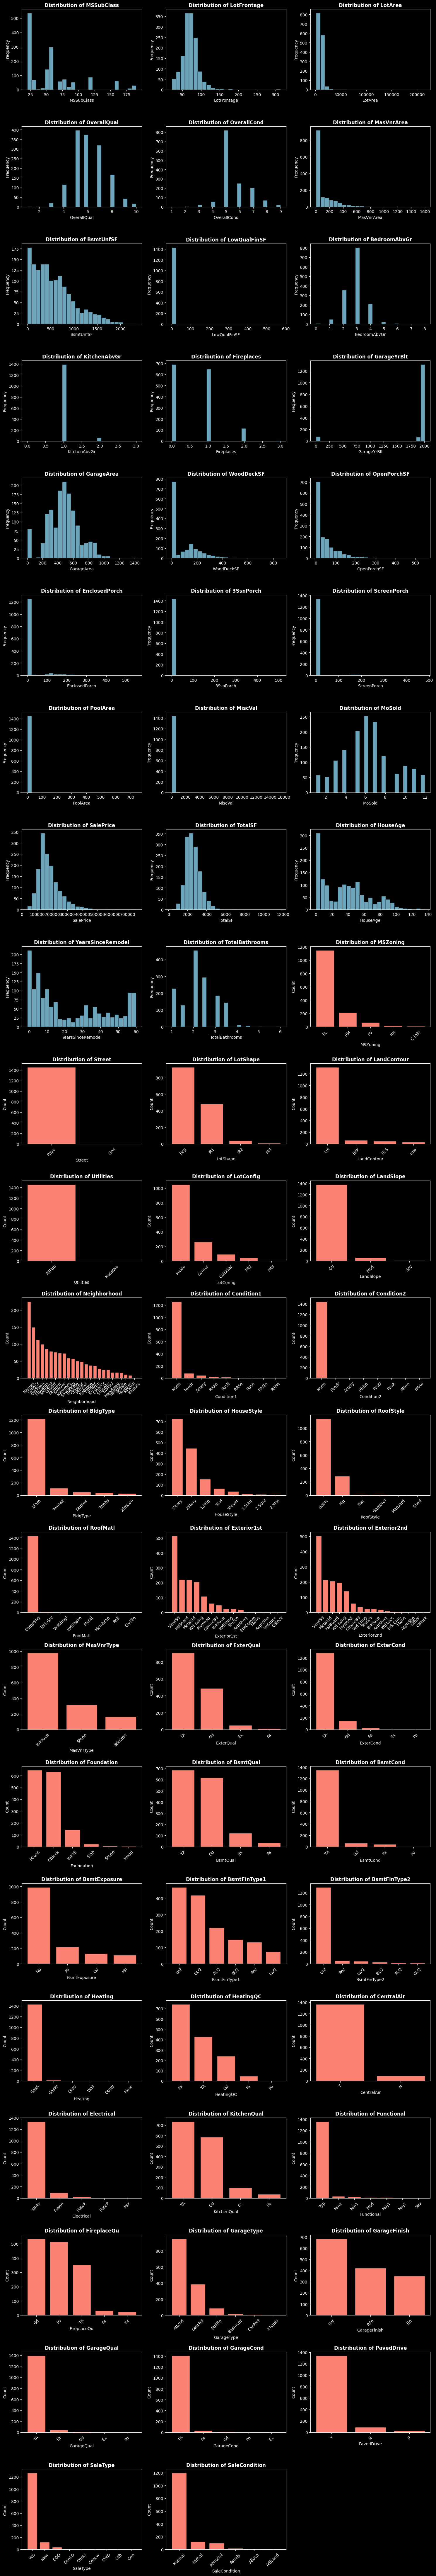

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Separate your columns by type
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(exclude=['number']).columns
all_features = list(numeric_cols) + list(categorical_cols)

# 2. Setup the grid layout (3 columns wide)
n_cols = 3
n_rows = (len(all_features) + n_cols - 1) // n_cols

# Use a dark background style to make white labels pop, 
# or set manually if you prefer a custom background.
plt.style.use('dark_background') 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Makes the grid easy to loop through

for i, col in enumerate(all_features):
    ax = axes[i]
    
    if col in numeric_cols:
        # NUMERIC: Plot a Histogram
        ax.hist(df[col].dropna(), bins=25, color='skyblue', edgecolor='black', alpha=0.8)
        ax.set_ylabel('Frequency', color='white')
    else:
        # CATEGORICAL: Plot a Bar Chart
        counts = df[col].value_counts()
        ax.bar(counts.index.astype(str), counts.values, color='salmon', edgecolor='black')
        ax.set_ylabel('Count', color='white')
        # Rotate x-labels if they are categorical strings
        ax.tick_params(axis='x', rotation=45)

    # Styling labels to WHITE
    ax.set_title(f'Distribution of {col}', color='white', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, color='white')
    ax.tick_params(colors='white') # Changes tick numbers to white
    
    # Optional: Make the plot border (spines) white
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

# 3. Clean up empty subplots (if features don't fill the last row perfectly)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [35]:
cols_to_remove = ["GarageCond","GarageQual","Street","Utilities", "Condition2", 'RoofMatl', "Heating","LowQualFinSF","KitchenAbvGr","EnclosedPorch","3SsnPorch","ScreenPorch","PoolArea","MiscVal"]

df.drop(columns=cols_to_remove)

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,WoodDeckSF,OpenPorchSF,MoSold,SaleType,SaleCondition,SalePrice,TotalSF,HouseAge,YearsSinceRemodel,TotalBathrooms
0,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,...,0,61,2,WD,Normal,208500,2566,5,5,3.5
1,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,Feedr,...,298,0,5,WD,Normal,181500,2524,31,31,2.5
2,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,...,0,42,9,WD,Normal,223500,2706,7,6,3.5
3,70,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,Norm,...,0,35,2,WD,Abnorml,140000,2473,91,36,2.0
4,60,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,Norm,...,192,84,12,WD,Normal,250000,3343,8,8,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Reg,Lvl,Inside,Gtl,Gilbert,Norm,...,0,40,8,WD,Normal,175000,2600,8,7,2.5
1456,20,RL,85.0,13175,Reg,Lvl,Inside,Gtl,NWAmes,Norm,...,349,0,2,WD,Normal,210000,3615,32,22,3.0
1457,70,RL,66.0,9042,Reg,Lvl,Inside,Gtl,Crawfor,Norm,...,0,60,5,WD,Normal,266500,3492,69,4,2.0
1458,20,RL,68.0,9717,Reg,Lvl,Inside,Gtl,NAmes,Norm,...,366,0,4,WD,Normal,142125,2156,60,14,2.0


1. Scaling

In [36]:
df4=df.copy()

Conducting StandardScaler Scaling

In [37]:
from sklearn.preprocessing import StandardScaler
numeric_cols = df4.select_dtypes(include=['number']).columns
cols_to_scale = [col for col in numeric_cols if col != 'SalePrice']

# 2. Initialize the StandardScaler (centers data around Mean=0, Std=1)
scaler = StandardScaler()

# 3. Fit and Transform ONLY the selected numerical data
df_standard_scaled = df4.copy()
df_standard_scaled[cols_to_scale] = scaler.fit_transform(df4[cols_to_scale])

# 4. Verify the scaling statistics for the modified columns
print("Mean values after scaling (Target is approximately 0.0):")
# Using round() because floating-point math might show numbers very close to 0 (e.g., 1e-16)
print(df_standard_scaled[cols_to_scale].mean().round(4).head())

print("\nStandard Deviation after scaling (Target is exactly 1.0):")
print(df_standard_scaled[cols_to_scale].std().round(4).head())

Mean values after scaling (Target is approximately 0.0):
MSSubClass    -0.0
LotFrontage   -0.0
LotArea       -0.0
OverallQual    0.0
OverallCond    0.0
dtype: float64

Standard Deviation after scaling (Target is exactly 1.0):
MSSubClass     1.0003
LotFrontage    1.0003
LotArea        1.0003
OverallQual    1.0003
OverallCond    1.0003
dtype: float64


1. Conducting MinMaxScaler

In [38]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# 1. Identify numerical columns BUT exclude 'SalePrice'
numeric_cols = df4.select_dtypes(include=['number']).columns
cols_to_scale = [col for col in numeric_cols if col != 'SalePrice']

# 2. Initialize the MinMaxScaler (scales data strictly between 0 and 1)
scaler = MinMaxScaler()

# 3. Fit and Transform ONLY the selected numerical data
df_minmax_scaled = df4.copy()
df_minmax_scaled[cols_to_scale] = scaler.fit_transform(df4[cols_to_scale])

# 4. Verify the scaling boundaries for the modified columns
print("Min values after scaling (Target is 0.0):")
print(df_minmax_scaled[cols_to_scale].min().sort_values())

print("\nMax values after scaling (Target is 1.0):")
print(df_minmax_scaled[cols_to_scale].max().sort_values())

# Verify SalePrice was left completely unscaled
print(f"\nSalePrice Range: {df_minmax_scaled['SalePrice'].min()} to {df_minmax_scaled['SalePrice'].max()}")

Min values after scaling (Target is 0.0):
MSSubClass           0.0
LotFrontage          0.0
LotArea              0.0
OverallQual          0.0
OverallCond          0.0
MasVnrArea           0.0
BsmtUnfSF            0.0
LowQualFinSF         0.0
BedroomAbvGr         0.0
KitchenAbvGr         0.0
Fireplaces           0.0
GarageYrBlt          0.0
GarageArea           0.0
WoodDeckSF           0.0
OpenPorchSF          0.0
EnclosedPorch        0.0
3SsnPorch            0.0
ScreenPorch          0.0
PoolArea             0.0
MiscVal              0.0
MoSold               0.0
TotalSF              0.0
HouseAge             0.0
YearsSinceRemodel    0.0
TotalBathrooms       0.0
dtype: float64

Max values after scaling (Target is 1.0):
LotArea              1.0
GarageYrBlt          1.0
WoodDeckSF           1.0
MoSold               1.0
OverallCond          1.0
MasVnrArea           1.0
LotFrontage          1.0
MSSubClass           1.0
LowQualFinSF         1.0
BsmtUnfSF            1.0
KitchenAbvGr         1.0


Conducting Yeo-Johnson Transforming for Gaussian distribution

In [39]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

# 1. Identify numerical columns BUT exclude 'SalePrice'
numeric_cols = df_standard_scaled.select_dtypes(include=['number']).columns
cols_to_transform = [col for col in numeric_cols if col != 'SalePrice']

# 2. Initialize the PowerTransformer with the 'yeo-johnson' method
pt = PowerTransformer(method='yeo-johnson', standardize=False)

# 3. Fit and Transform ONLY the selected numerical data
# We create a copy to keep the original dataframe intact
df_transformed_standard_scaled = df_standard_scaled.copy()
df_transformed_standard_scaled[cols_to_transform] = pt.fit_transform(df_standard_scaled[cols_to_transform])

# 4. Check the new skewness of the transformed columns
new_skew = df_transformed_standard_scaled[cols_to_transform].skew().sort_values(ascending=False)
print("New Skewness after Yeo-Johnson (Target is 0):")
print(new_skew)

# Verify SalePrice was left completely unscaled
print("\nOriginal SalePrice Mean:", df4['SalePrice'].mean())
print("Transformed DataFrame SalePrice Mean:", df_transformed_standard_scaled['SalePrice'].mean())

New Skewness after Yeo-Johnson (Target is 0):
PoolArea             14.352680
3SsnPorch             7.613746
LowQualFinSF          7.299413
MiscVal               5.016996
ScreenPorch           3.113276
EnclosedPorch         2.053944
MasVnrArea            0.673451
WoodDeckSF            0.400827
OpenPorchSF           0.370393
MSSubClass            0.222993
Fireplaces            0.215296
YearsSinceRemodel     0.192109
HouseAge              0.129779
BedroomAbvGr          0.120203
BsmtUnfSF             0.096754
TotalBathrooms        0.030234
GarageArea            0.019970
LotFrontage           0.007653
TotalSF               0.004947
MoSold               -0.012439
OverallQual          -0.036970
LotArea              -0.267855
OverallCond          -0.328936
GarageYrBlt          -1.293295
KitchenAbvGr         -8.573974
dtype: float64

Original SalePrice Mean: 180921.19589041095
Transformed DataFrame SalePrice Mean: 180921.19589041095


In [40]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

# 1. Identify numerical columns BUT exclude 'SalePrice'
numeric_cols = df_minmax_scaled.select_dtypes(include=['number']).columns
cols_to_transform = [col for col in numeric_cols if col != 'SalePrice']

# 2. Initialize the PowerTransformer with the 'yeo-johnson' method
pt = PowerTransformer(method='yeo-johnson', standardize=False)

# 3. Fit and Transform ONLY the selected numerical data
# We create a copy to keep the original dataframe intact
df_transformed_minmax_scaled = df_standard_scaled.copy()
df_transformed_minmax_scaled[cols_to_transform] = pt.fit_transform(df_standard_scaled[cols_to_transform])

# 4. Check the new skewness of the transformed columns
new_skew = df_transformed_minmax_scaled[cols_to_transform].skew().sort_values(ascending=False)
print("New Skewness after Yeo-Johnson (Target is 0):")
print(new_skew)

# Verify SalePrice was left completely unscaled
print("\nOriginal SalePrice Mean:", df4['SalePrice'].mean())
print("Transformed DataFrame SalePrice Mean:", df_transformed_minmax_scaled['SalePrice'].mean())

New Skewness after Yeo-Johnson (Target is 0):
PoolArea             14.352680
3SsnPorch             7.613746
LowQualFinSF          7.299413
MiscVal               5.016996
ScreenPorch           3.113276
EnclosedPorch         2.053944
MasVnrArea            0.673451
WoodDeckSF            0.400827
OpenPorchSF           0.370393
MSSubClass            0.222993
Fireplaces            0.215296
YearsSinceRemodel     0.192109
HouseAge              0.129779
BedroomAbvGr          0.120203
BsmtUnfSF             0.096754
TotalBathrooms        0.030234
GarageArea            0.019970
LotFrontage           0.007653
TotalSF               0.004947
MoSold               -0.012439
OverallQual          -0.036970
LotArea              -0.267855
OverallCond          -0.328936
GarageYrBlt          -1.293295
KitchenAbvGr         -8.573974
dtype: float64

Original SalePrice Mean: 180921.19589041095
Transformed DataFrame SalePrice Mean: 180921.19589041095


In [41]:
summary_df = pd.DataFrame({
    'Min': df_transformed_minmax_scaled[cols_to_scale].min(),
    'Max': df_transformed_minmax_scaled[cols_to_scale].max()
})

print(summary_df)

                         Min       Max
MSSubClass         -1.259392  1.409524
LotFrontage        -2.769584  5.698519
LotArea            -1.546608  1.911168
OverallQual        -4.207938  2.530308
OverallCond        -6.100255  2.259935
MasVnrArea         -0.982836  0.836036
BsmtUnfSF          -1.748353  2.192811
LowQualFinSF       -0.842678  0.038033
BedroomAbvGr       -3.606712  6.074411
KitchenAbvGr      -14.273159  2.542175
Fireplaces         -1.143514  2.369477
GarageYrBlt        -0.232662  0.716580
GarageArea         -2.313465  4.131548
WoodDeckSF         -1.117275  1.578930
OpenPorchSF        -1.106860  1.350236
EnclosedPorch      -0.892829  0.247153
3SsnPorch          -0.832603  0.036458
ScreenPorch        -0.814180  0.147833
PoolArea           -0.757993  0.018168
MiscVal            -0.351888  0.037601
MoSold             -2.164825  1.906691
TotalSF            -3.982259  5.267608
HouseAge           -1.508400  2.174216
YearsSinceRemodel  -1.552912  1.239011
TotalBathrooms     -1.671

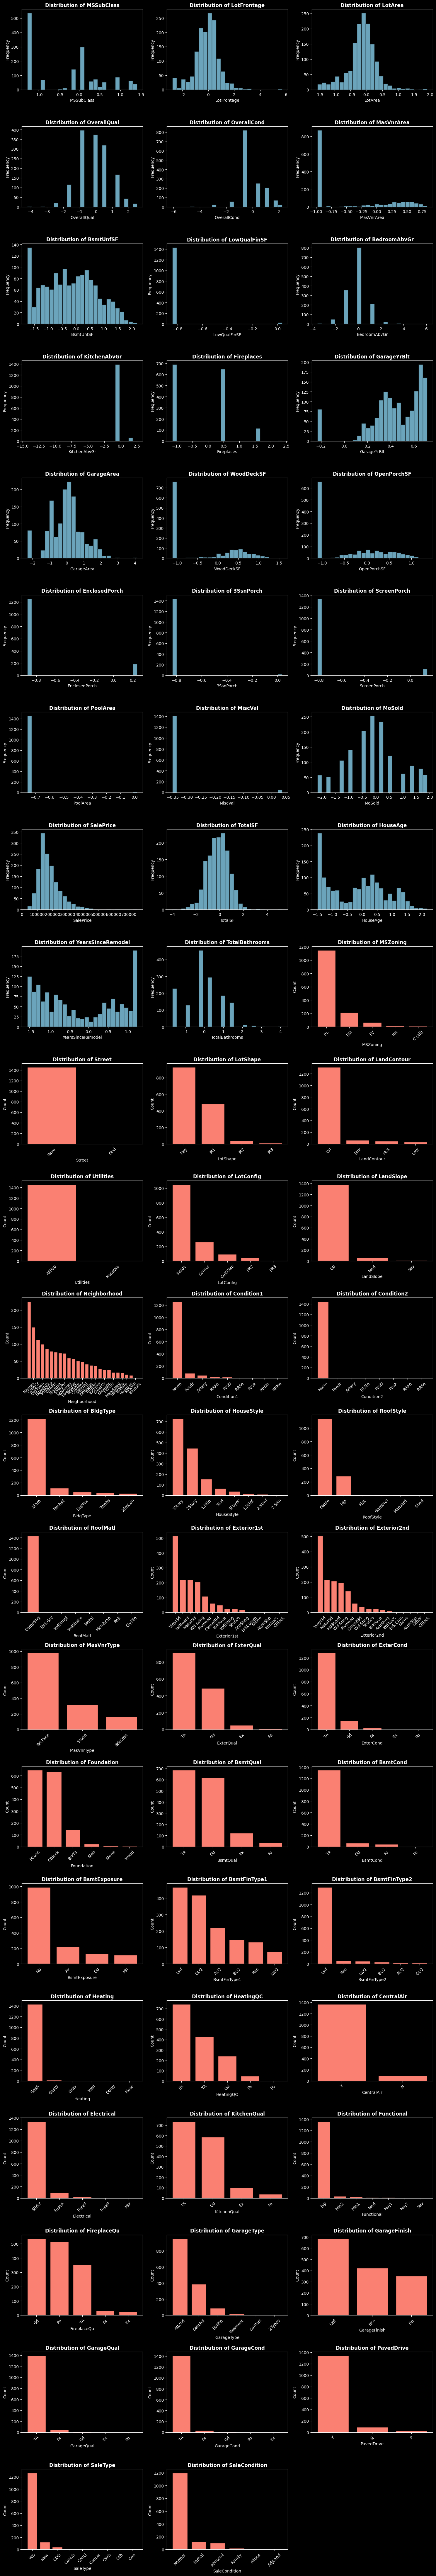

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Separate your columns by type
numeric_cols = df_transformed_standard_scaled.select_dtypes(include=['number']).columns
categorical_cols = df_transformed_standard_scaled.select_dtypes(exclude=['number']).columns
all_features = list(numeric_cols) + list(categorical_cols)

# 2. Setup the grid layout (3 columns wide)
n_cols = 3
n_rows = (len(all_features) + n_cols - 1) // n_cols

# Use a dark background style to make white labels pop, 
# or set manually if you prefer a custom background.
plt.style.use('dark_background') 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Makes the grid easy to loop through

for i, col in enumerate(all_features):
    ax = axes[i]
    
    if col in numeric_cols:
        # NUMERIC: Plot a Histogram
        ax.hist(df_transformed_standard_scaled[col].dropna(), bins=25, color='skyblue', edgecolor='black', alpha=0.8)
        ax.set_ylabel('Frequency', color='white')
    else:
        # CATEGORICAL: Plot a Bar Chart
        counts =df_transformed_standard_scaled[col].value_counts()
        ax.bar(counts.index.astype(str), counts.values, color='salmon', edgecolor='black')
        ax.set_ylabel('Count', color='white')
        # Rotate x-labels if they are categorical strings
        ax.tick_params(axis='x', rotation=45)

    # Styling labels to WHITE
    ax.set_title(f'Distribution of {col}', color='white', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, color='white')
    ax.tick_params(colors='white') # Changes tick numbers to white
    
    # Optional: Make the plot border (spines) white
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

# 3. Clean up empty subplots (if features don't fill the last row perfectly)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

1. Plotting for MinMaxScaler 

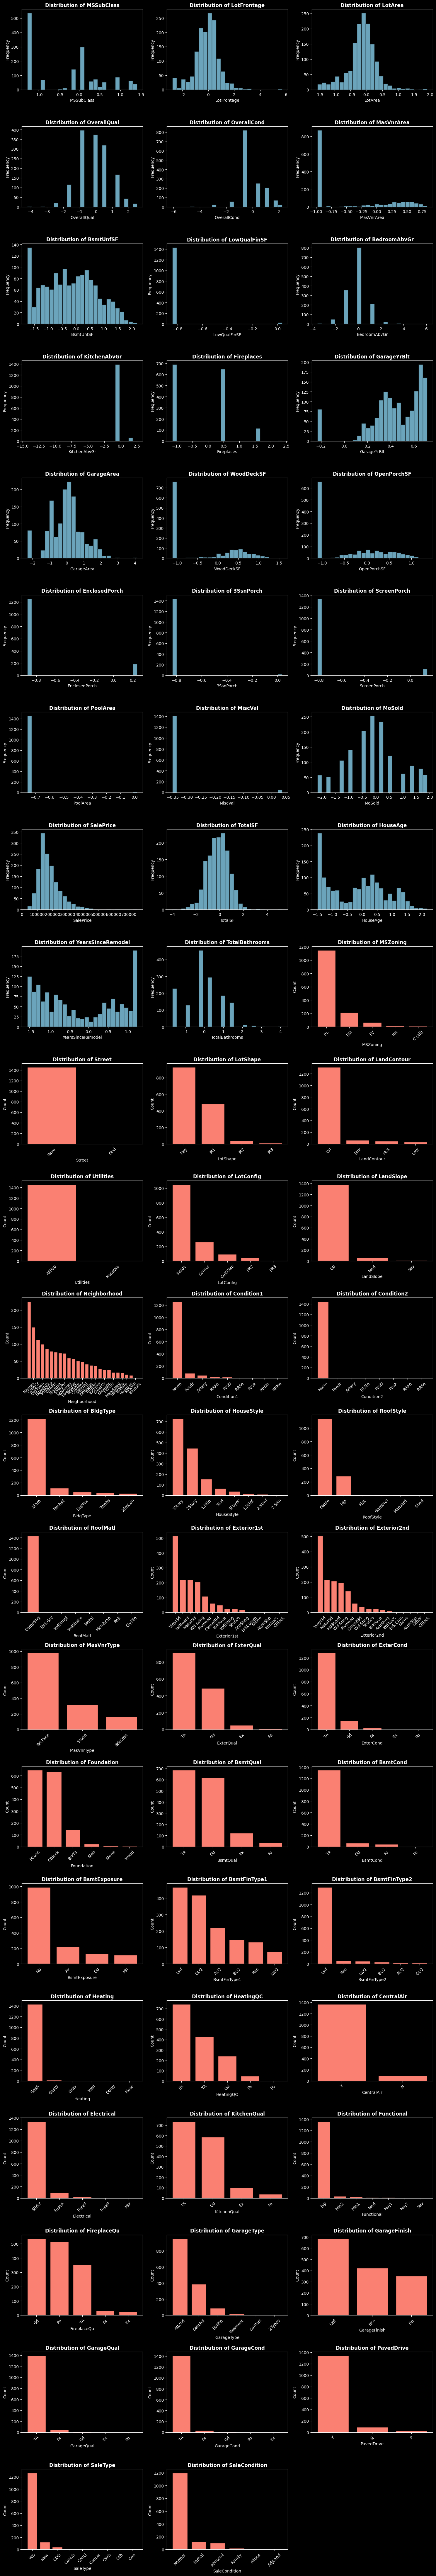

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Separate your columns by type
numeric_cols = df_transformed_minmax_scaled.select_dtypes(include=['number']).columns
categorical_cols = df_transformed_minmax_scaled.select_dtypes(exclude=['number']).columns
all_features = list(numeric_cols) + list(categorical_cols)

# 2. Setup the grid layout (3 columns wide)
n_cols = 3
n_rows = (len(all_features) + n_cols - 1) // n_cols

# Use a dark background style to make white labels pop, 
# or set manually if you prefer a custom background.
plt.style.use('dark_background') 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Makes the grid easy to loop through

for i, col in enumerate(all_features):
    ax = axes[i]
    
    if col in numeric_cols:
        # NUMERIC: Plot a Histogram
        ax.hist(df_transformed_minmax_scaled[col].dropna(), bins=25, color='skyblue', edgecolor='black', alpha=0.8)
        ax.set_ylabel('Frequency', color='white')
    else:
        # CATEGORICAL: Plot a Bar Chart
        counts =df_transformed_minmax_scaled[col].value_counts()
        ax.bar(counts.index.astype(str), counts.values, color='salmon', edgecolor='black')
        ax.set_ylabel('Count', color='white')
        # Rotate x-labels if they are categorical strings
        ax.tick_params(axis='x', rotation=45)

    # Styling labels to WHITE
    ax.set_title(f'Distribution of {col}', color='white', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, color='white')
    ax.tick_params(colors='white') # Changes tick numbers to white
    
    # Optional: Make the plot border (spines) white
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

# 3. Clean up empty subplots (if features don't fill the last row perfectly)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

1. One Hot Encoding

In [44]:
df_encoded_standard = pd.get_dummies(df_transformed_standard_scaled, drop_first=True, dtype=int)

print(df_encoded_standard.head())

   MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  MasVnrArea  \
0    0.070775    -0.250534 -0.236484     0.628127    -0.562290    0.333653   
1   -1.259392     0.377651 -0.097590    -0.072178     1.701699   -0.982836   
2    0.070775    -0.113624  0.070064     0.628127    -0.562290    0.242824   
3    0.269449    -0.490759 -0.103244     0.628127    -0.562290   -0.982836   
4    0.070775     0.525394  0.302033     1.286777    -0.562290    0.558486   

   BsmtUnfSF  LowQualFinSF  BedroomAbvGr  KitchenAbvGr  ...  SaleType_ConLI  \
0  -1.202425     -0.842678      0.163430     -0.231676  ...               0   
1  -0.763189     -0.842678      0.163430     -0.231676  ...               0   
2  -0.329539     -0.842678      0.163430     -0.231676  ...               0   
3  -0.062867     -0.842678      0.163430     -0.231676  ...               0   
4  -0.184368     -0.842678      1.371172     -0.231676  ...               0   

   SaleType_ConLw  SaleType_New  SaleType_Oth  SaleType_

In [45]:
df_encoded_minmax = pd.get_dummies(df_transformed_minmax_scaled, drop_first=True, dtype=int)

print(df_encoded_minmax.head())

   MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  MasVnrArea  \
0    0.070775    -0.250534 -0.236484     0.628127    -0.562290    0.333653   
1   -1.259392     0.377651 -0.097590    -0.072178     1.701699   -0.982836   
2    0.070775    -0.113624  0.070064     0.628127    -0.562290    0.242824   
3    0.269449    -0.490759 -0.103244     0.628127    -0.562290   -0.982836   
4    0.070775     0.525394  0.302033     1.286777    -0.562290    0.558486   

   BsmtUnfSF  LowQualFinSF  BedroomAbvGr  KitchenAbvGr  ...  SaleType_ConLI  \
0  -1.202425     -0.842678      0.163430     -0.231676  ...               0   
1  -0.763189     -0.842678      0.163430     -0.231676  ...               0   
2  -0.329539     -0.842678      0.163430     -0.231676  ...               0   
3  -0.062867     -0.842678      0.163430     -0.231676  ...               0   
4  -0.184368     -0.842678      1.371172     -0.231676  ...               0   

   SaleType_ConLw  SaleType_New  SaleType_Oth  SaleType_

In [46]:
df_encoded_standard["SalePrice"]

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [47]:
df_encoded_minmax["SalePrice"]

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

Deriving new Categoric Feature based 'SalePrice' with ['Budget', 'Standard', 'Premium'] categories

1. Equal Frequency Binning

In [61]:
df_encoded_standard['Price_Category'] = pd.qcut(
    df_encoded_standard['SalePrice'], 
    q=3, 
    labels=['Budget', 'Standard', 'Premium']
)
print(df_encoded_standard['Price_Category'].value_counts())
print("\n--- Calculated Tree Bin Edges ---")
print(f"Budget boundary:  ${df_encoded_standard['SalePrice'].min():,} to ${round(tree_thresholds[0]):,}")
print(f"Standard boundary:${round(tree_thresholds[0]):,} to ${round(tree_thresholds[1]):,}")
print(f"Premium boundary: ${round(tree_thresholds[1]):,} to ${df_encoded_standard['SalePrice'].max():,}")

Price_Category
Standard    490
Budget      487
Premium     483
Name: count, dtype: int64

--- Calculated Tree Bin Edges ---
Budget boundary:  $34,900 to $220,500
Standard boundary:$220,500 to $352,000
Premium boundary: $352,000 to $755,000


2. Equal-Width Binning

In [63]:
df_encoded_standard['Price_Category'] = pd.cut(df_encoded_standard['SalePrice'], bins=3, labels=['Budget', 'Standard', 'Premium'])
print(df_encoded_standard['Price_Category'].value_counts())


Price_Category
Budget      1302
Standard     150
Premium        8
Name: count, dtype: int64


3.K-Means Binning

In [53]:
from sklearn.preprocessing import KBinsDiscretizer
import pandas as pd

# 1. Initialize KBinsDiscretizer using K-Means strategy
# n_bins=3 creates our three categories
# encode='ordinal' returns integer codes (0, 1, 2)
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='kmeans', random_state=42)

# 2. Fit and transform the SalePrice column
# We reshape the column using .values.reshape(-1, 1) because the discretizer expects a 2D array
df_encoded_standard['Price_Category_Code'] = kbd.fit_transform(df_encoded_standard[['SalePrice']]).astype(int)

# 3. Map the numerical codes back to your text labels
# K-Means naturally orders bins from lowest value to highest value
label_map = {0: 'Budget', 1: 'Standard', 2: 'Premium'}
df_encoded_standard['Price_Category'] = df_encoded_standard['Price_Category_Code'].map(label_map)

# 4. Verify the distribution and see the exact cluster edges
print("--- K-Means Class Distribution ---")
print(df_encoded_standard['Price_Category'].value_counts())

print("\n--- Calculated Bin Edges ---")
edges = kbd.bin_edges_[0]
print(f"Budget boundary:  ${round(edges[0]):,} to ${round(edges[1]):,}")
print(f"Standard boundary:${round(edges[1]):,} to ${round(edges[2]):,}")
print(f"Premium boundary: ${round(edges[2]):,} to ${round(edges[3]):,}")

--- K-Means Class Distribution ---
Price_Category
Budget      826
Standard    518
Premium     116
Name: count, dtype: int64

--- Calculated Bin Edges ---
Budget boundary:  $34,900 to $174,854
Standard boundary:$174,854 to $297,011
Premium boundary: $297,011 to $755,000


4. Decision Tree Binning

In [55]:
from sklearn.tree import DecisionTreeRegressor
import pandas as pd
import numpy as np

# 1. Initialize a shallow Decision Tree Regressor
# max_leaf_nodes=3 forces the tree to make exactly 3 terminal bins (Budget, Standard, Premium)
dt_binner = DecisionTreeRegressor(max_leaf_nodes=3, random_state=42)

# 2. Extract SalePrice as both X (feature) and y (target)
# We reshape X to 2D array because sklearn requires it
X = df_encoded_standard[['SalePrice']]
y = df_encoded_standard['SalePrice']

# 3. Fit the model to find the optimal splits
dt_binner.fit(X, y)

# 4. Use the model's leaf node predictions to get the category thresholds
# The tree outputs the mean value of the leaf node it falls into
df_encoded_standard['Tree_Leaves'] = dt_binner.predict(X)

# 5. Map the unique prediction leaves to our ordered text categories
# Sort the unique leaves to ensure lowest mean value maps to Budget and highest to Premium
unique_leaves = sorted(df_encoded_standard['Tree_Leaves'].unique())
leaf_map = {
    unique_leaves[0]: 'Budget',
    unique_leaves[1]: 'Standard',
    unique_leaves[2]: 'Premium'
}

df_encoded_standard['Price_Category'] = df_encoded_standard['Tree_Leaves'].map(leaf_map)

# 6. Extract the exact cut thresholds chosen by the tree thresholds
# We look at the internal split values inside the tree structure
tree_thresholds = sorted(dt_binner.tree_.threshold[dt_binner.tree_.threshold != -2])

# Print out the results
print("--- Decision Tree Class Distribution ---")
print(df_encoded_standard['Price_Category'].value_counts())

print("\n--- Calculated Tree Bin Edges ---")
print(f"Budget boundary:  ${df_encoded_standard['SalePrice'].min():,} to ${round(tree_thresholds[0]):,}")
print(f"Standard boundary:${round(tree_thresholds[0]):,} to ${round(tree_thresholds[1]):,}")
print(f"Premium boundary: ${round(tree_thresholds[1]):,} to ${df_encoded_standard['SalePrice'].max():,}")

# Drop temporary column
df_encoded_standard = df_encoded_standard.drop(columns=['Tree_Leaves'])

--- Decision Tree Class Distribution ---
Price_Category
Budget      1125
Standard     281
Premium       54
Name: count, dtype: int64

--- Calculated Tree Bin Edges ---
Budget boundary:  $34,900 to $220,500
Standard boundary:$220,500 to $352,000
Premium boundary: $352,000 to $755,000


5. Statistical Deviation (Standard Score / Z-score) Binning

In [57]:
import pandas as pd
import numpy as np

# 1. Calculate the mean (\u03bc) and standard deviation (\u03c3) of SalePrice
mean_price = df_encoded_standard['SalePrice'].mean()
std_price = df_encoded_standard['SalePrice'].std()

# 2. Define the mathematical thresholds
lower_threshold = mean_price - std_price
upper_threshold = mean_price + std_price

# 3. Create the bin edges using -inf and +inf for the absolute limits
# Budget:  -inf to (\u03bc - \u03c3)
# Standard: (\u03bc - \u03c3) to (\u03bc + \u03c3)
# Premium:  (\u03bc + \u03c3) to +inf
bin_edges = [-np.inf, lower_threshold, upper_threshold, np.inf]
labels = ['Budget', 'Standard', 'Premium']

# 4. Run the binning operation
df_encoded_standard['Price_Category'] = pd.cut(
    df_encoded_standard['SalePrice'], 
    bins=bin_edges, 
    labels=labels
)

# 5. Verify the results and display the class distribution
print("--- Statistical Deviation Class Distribution ---")
print(df_encoded_standard['Price_Category'].value_counts())

print("\n--- Calculated Z-Score Thresholds ---")
print(f"Mean Price (\u03bc): ${round(mean_price):,}")
print(f"Std Dev (\u03c3):    ${round(std_price):,}")
print(f"Budget range:     Min (${df_encoded_standard['SalePrice'].min():,}) to ${round(lower_threshold):,}")
print(f"Standard range:   ${round(lower_threshold):,} to ${round(upper_threshold):,}")
print(f"Premium range:    ${round(upper_threshold):,} to Max (${df_encoded_standard['SalePrice'].max():,})")

--- Statistical Deviation Class Distribution ---
Price_Category
Standard    1145
Premium      191
Budget       124
Name: count, dtype: int64

--- Calculated Z-Score Thresholds ---
Mean Price (μ): $180,921
Std Dev (σ):    $79,443
Budget range:     Min ($34,900) to $101,479
Standard range:   $101,479 to $260,364
Premium range:    $260,364 to Max ($755,000)
